# 🏨 Hotel & Resort Room Image Classifier

A complete PyTorch implementation for classifying 26 different classes of hotel and resort rooms using **ConvNeXt-Tiny** architecture.

## Features:
- ✅ State-of-the-art ConvNeXt-Tiny architecture
- ✅ Two-stage fine-tuning strategy
- ✅ Robust data augmentation for indoor photography
- ✅ Label smoothing for similar classes
- ✅ Professional training infrastructure
- ✅ Easy inference on new images

## 📦 Installation & Imports

In [1]:
# Install required packages (run this cell first)
!pip install torch torchvision timm tqdm Pillow numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from timm.loss import LabelSmoothingCrossEntropy
from tqdm.notebook import tqdm
from pathlib import Path
from PIL import Image
import numpy as np
from typing import Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cpu
CUDA available: False


In [3]:
# Ensure ipywidgets and ipywidgets extensions are installed for tqdm notebook progress bars
!pip install ipywidgets --quiet
!jupyter nbextension enable --py widgetsnbextension --sys-prefix


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
usage: python.exe c:\Users\sanja\AppData\Roaming\Python\Python314\Scripts\jupyter
       [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir] [--paths]
       [--json] [--debug]
       [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbextension` not found

## ⚙️ Configuration & Hyperparameters

In [ ]:
class Config:
    """Central configuration for all hyperparameters"""
    
    # Data parameters
    DATA_DIR = "Annotated_Data"  # Root directory with train/val subdirectories
    NUM_CLASSES = 14
    IMG_SIZE = 224  # ConvNeXt standard input size
    
    # Training parameters
    BATCH_SIZE = 32
    NUM_EPOCHS = 15
    NUM_WORKERS = 4
    
    # Optimizer parameters
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 0.05
    LABEL_SMOOTHING = 0.1
    
    # Two-stage fine-tuning
    FREEZE_EPOCHS = 10  # Number of epochs to train with frozen backbone
    
    # Paths
    CHECKPOINT_DIR = "checkpoints_03_03"
    BEST_MODEL_PATH = "checkpoints_03_03/hotel_classifier.pth"
    CLASS_NAMES_PATH = "checkpoints_03_03/class_names.json"
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Reproducibility
    SEED = 42

# Display configuration
print("Configuration:")
print(f"  Device: {Config.DEVICE}")
print(f"  Batch Size: {Config.BATCH_SIZE}")
print(f"  Learning Rate: {Config.LEARNING_RATE}")
print(f"  Total Epochs: {Config.NUM_EPOCHS}")
print(f"  Image Size: {Config.IMG_SIZE}x{Config.IMG_SIZE}")

Configuration:
  Device: cpu
  Batch Size: 32
  Learning Rate: 0.0001
  Total Epochs: 15
  Image Size: 224x224


## 📁 Data Preparation

### Expected Directory Structure:
```
data/hotel_rooms/
    train/
        class1/
            img1.jpg
            img2.jpg
        class2/
            ...
    val/
        class1/
            ...
        class2/
            ...
```

In [5]:
# Automatically split images into train/val (80/20) and organize folders
import os
import shutil
import random
from glob import glob

# Set random seed for reproducibility
random.seed(42)

# Source directory containing class folders (update if needed)
source_dir = "Annotated_Data"
train_dir = os.path.join(source_dir, "train")
val_dir = os.path.join(source_dir, "val")

# List all class folders (ignore train/val if already present)
all_classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d)) and d not in ["train", "val"]]

for class_name in all_classes:
    class_path = os.path.join(source_dir, class_name)
    images = glob(os.path.join(class_path, "*"))
    random.shuffle(images)
    n_total = len(images)
    n_train = int(0.8 * n_total)
    train_images = images[:n_train]
    val_images = images[n_train:]

    # Create class subfolders in train/val
    train_class_dir = os.path.join(train_dir, class_name)
    val_class_dir = os.path.join(val_dir, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)

    # Move images
    for img_path in train_images:
        shutil.move(img_path, os.path.join(train_class_dir, os.path.basename(img_path)))
    for img_path in val_images:
        shutil.move(img_path, os.path.join(val_class_dir, os.path.basename(img_path)))

    print(f"Class '{class_name}': {len(train_images)} train, {len(val_images)} val images moved.")

print("\nSplit complete! Your data is now organized for training.")

Class 'Bathroom': 152 train, 39 val images moved.
Class 'BBQ': 32 train, 8 val images moved.
Class 'Bedroom': 342 train, 86 val images moved.
Class 'Common Space': 80 train, 20 val images moved.
Class 'Dining Room': 140 train, 36 val images moved.
Class 'Exterior': 133 train, 34 val images moved.
Class 'Gym room': 59 train, 15 val images moved.
Class 'Kitchen': 147 train, 37 val images moved.
Class 'Living room': 279 train, 70 val images moved.
Class 'Lounge': 93 train, 24 val images moved.
Class 'Play Area': 87 train, 22 val images moved.
Class 'Study Room': 60 train, 15 val images moved.
Class 'Swimming pool': 115 train, 29 val images moved.
Class 'View': 90 train, 23 val images moved.

Split complete! Your data is now organized for training.


In [6]:
# Create required data directories if they do not exist
import os

required_dirs = ["Annotated_Data/train", "Annotated_Data/val"]
for d in required_dirs:
    if not os.path.exists(d):
        os.makedirs(d, exist_ok=True)
        print(f'Created directory: {d}')
    else:
        print(f'Directory already exists: {d}')

print('\nPlease organize your images into class subfolders inside Annotated_Data/train and Annotated_Data/val as described above.')

Directory already exists: Annotated_Data/train
Directory already exists: Annotated_Data/val

Please organize your images into class subfolders inside Annotated_Data/train and Annotated_Data/val as described above.


In [7]:
def get_transforms(is_training: bool = True) -> transforms.Compose:
    """
    Get data augmentation transforms optimized for indoor architectural photography.
    
    Args:
        is_training: Whether to apply training augmentations
        
    Returns:
        Composed transforms
    """
    if is_training:
        return transforms.Compose([
            # Resize to slightly larger than target, then random crop
            transforms.Resize(256),
            transforms.RandomResizedCrop(
                Config.IMG_SIZE, 
                scale=(0.8, 1.0),  # Mild crop to preserve room context
                ratio=(0.9, 1.1)   # Maintain aspect ratio for architectural shots
            ),
            
            # Horizontal flip (rooms can be mirrored)
            transforms.RandomHorizontalFlip(p=0.5),
            
            # Color jitter for varying lighting conditions
            transforms.ColorJitter(
                brightness=0.2,   # Account for different lighting
                contrast=0.2,     # Different camera settings
                saturation=0.15,  # Slight color variation
                hue=0.05          # Minimal hue shift to preserve room colors
            ),
            
            # Random rotation (very slight, to avoid distortion)
            transforms.RandomRotation(degrees=5),
            
            # Convert to tensor and normalize with ImageNet stats
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    else:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(Config.IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

print("✓ Data transforms defined")

✓ Data transforms defined


In [8]:
def create_dataloaders() -> Tuple[DataLoader, DataLoader, list]:
    """
    Create training and validation DataLoaders using ImageFolder structure.
    
    Returns:
        train_loader, val_loader, class_names
    """
    train_dir = os.path.join(Config.DATA_DIR, 'train')
    val_dir = os.path.join(Config.DATA_DIR, 'val')
    
    # Verify directories exist
    if not os.path.exists(train_dir):
        raise FileNotFoundError(f"Training directory not found: {train_dir}")
    if not os.path.exists(val_dir):
        raise FileNotFoundError(f"Validation directory not found: {val_dir}")
    
    # Create datasets
    train_dataset = datasets.ImageFolder(
        train_dir,
        transform=get_transforms(is_training=True)
    )
    
    val_dataset = datasets.ImageFolder(
        val_dir,
        transform=get_transforms(is_training=False)
    )
    
    # Extract class names
    class_names = train_dataset.classes
    print(f"Found {len(class_names)} classes: {class_names}")
    
    # Verify number of classes
    assert len(class_names) == Config.NUM_CLASSES, \
        f"Expected {Config.NUM_CLASSES} classes, found {len(class_names)}"
    
    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True if Config.DEVICE.type == 'cuda' else False,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True if Config.DEVICE.type == 'cuda' else False
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Training batches: {len(train_loader)}")
    print(f"Validation batches: {len(val_loader)}")
    
    return train_loader, val_loader, class_names

## 🏗️ Model Architecture

In [9]:
class HotelRoomClassifier(nn.Module):
    """
    ConvNeXt-Tiny based classifier for hotel room categorization.
    Supports two-stage fine-tuning with layer freezing.
    """
    
    def __init__(self, num_classes: int = 26, pretrained: bool = True):
        """
        Initialize the classifier.
        
        Args:
            num_classes: Number of room categories
            pretrained: Whether to use ImageNet pretrained weights
        """
        super(HotelRoomClassifier, self).__init__()
        
        # Load ConvNeXt-Tiny from timm
        self.model = timm.create_model(
            'convnext_tiny',
            pretrained=pretrained,
            num_classes=num_classes
        )
        
        print(f"Model created with {num_classes} output classes")
        print(f"Pretrained: {pretrained}")
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass"""
        return self.model(x)
    
    def freeze_backbone(self):
        """
        Freeze all layers except the classification head.
        Used in first stage of two-stage fine-tuning.
        """
        # Freeze all parameters
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze the head (classifier)
        for param in self.model.head.parameters():
            param.requires_grad = True
        
        print("✓ Backbone frozen - only training classification head")
    
    def unfreeze_all(self):
        """
        Unfreeze all layers for full fine-tuning.
        Used in second stage of two-stage fine-tuning.
        """
        for param in self.model.parameters():
            param.requires_grad = True
        
        print("✓ All layers unfrozen - full model training")
    
    def get_trainable_params(self) -> int:
        """Get count of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("✓ Model architecture defined")

✓ Model architecture defined


## 🎯 Training Functions

In [10]:
def train_one_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epoch: int
) -> Tuple[float, float]:
    """
    Train the model for one epoch.
    
    Returns:
        average_loss, accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False)
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f"{running_loss/(batch_idx+1):.4f}",
            'acc': f"{100.*correct/total:.2f}%"
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(
    model: nn.Module,
    val_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    epoch: int
) -> Tuple[float, float]:
    """
    Validate the model.
    
    Returns:
        average_loss, accuracy
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(val_loader, desc=f"Epoch {epoch} [Val]", leave=False)
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f"{running_loss/(batch_idx+1):.4f}",
                'acc': f"{100.*correct/total:.2f}%"
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

print("✓ Training functions defined")

✓ Training functions defined


## 🚀 Main Training Loop

This implements the two-stage fine-tuning strategy:
- **Stage 1**: Train only classification head with frozen backbone
- **Stage 2**: Fine-tune entire model

In [11]:
def train_model():
    """
    Main training function implementing two-stage fine-tuning strategy.
    """
    # Set random seeds
    torch.manual_seed(Config.SEED)
    np.random.seed(Config.SEED)
    
    # Create checkpoint directory
    os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
    
    print("="*70)
    print("HOTEL ROOM CLASSIFICATION TRAINING")
    print("="*70)
    print(f"Device: {Config.DEVICE}")
    print(f"Image Size: {Config.IMG_SIZE}x{Config.IMG_SIZE}")
    print(f"Batch Size: {Config.BATCH_SIZE}")
    print(f"Learning Rate: {Config.LEARNING_RATE}")
    print(f"Total Epochs: {Config.NUM_EPOCHS}")
    print(f"Two-Stage Training: {Config.FREEZE_EPOCHS} frozen + {Config.NUM_EPOCHS - Config.FREEZE_EPOCHS} unfrozen")
    print("="*70)
    
    # Load data
    print("\n📁 Loading data...")
    train_loader, val_loader, class_names = create_dataloaders()
    
    # Save class names
    with open(Config.CLASS_NAMES_PATH, 'w') as f:
        json.dump(class_names, f, indent=2)
    print(f"✓ Class names saved to {Config.CLASS_NAMES_PATH}")
    
    # Create model
    print("\n🏗️  Building model...")
    model = HotelRoomClassifier(
        num_classes=Config.NUM_CLASSES,
        pretrained=True
    ).to(Config.DEVICE)
    
    # Loss, optimizer, scheduler
    criterion = LabelSmoothingCrossEntropy(smoothing=Config.LABEL_SMOOTHING)
    optimizer = AdamW(
        model.parameters(),
        lr=Config.LEARNING_RATE,
        weight_decay=Config.WEIGHT_DECAY
    )
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=Config.NUM_EPOCHS,
        eta_min=1e-6
    )
    
    # Training tracking
    best_val_acc = 0.0
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }
    
    print("\n🚀 Starting training...\n")
    
    for epoch in range(1, Config.NUM_EPOCHS + 1):
        # Stage 1: Freeze backbone
        if epoch == 1:
            model.freeze_backbone()
            print(f"Stage 1: Training classification head only ({Config.FREEZE_EPOCHS} epochs)")
            print(f"Trainable parameters: {model.get_trainable_params():,}\n")
        
        # Stage 2: Unfreeze all
        if epoch == Config.FREEZE_EPOCHS + 1:
            model.unfreeze_all()
            print(f"\nStage 2: Fine-tuning entire model ({Config.NUM_EPOCHS - Config.FREEZE_EPOCHS} epochs)")
            print(f"Trainable parameters: {model.get_trainable_params():,}\n")
        
        # Train and validate
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, Config.DEVICE, epoch
        )
        
        val_loss, val_acc = validate(
            model, val_loader, criterion, Config.DEVICE, epoch
        )
        
        # Update scheduler
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Print epoch summary
        print(f"\nEpoch {epoch}/{Config.NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  LR: {current_lr:.6f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_names': class_names,
                'config': {
                    'num_classes': Config.NUM_CLASSES,
                    'img_size': Config.IMG_SIZE,
                }
            }, Config.BEST_MODEL_PATH)
            print(f"  ✓ New best model saved! (Val Acc: {val_acc:.2f}%)")
        
        print("-" * 70)
    
    print("\n" + "="*70)
    print("TRAINING COMPLETE!")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"Best model saved to: {Config.BEST_MODEL_PATH}")
    print("="*70)
    
    return model, history, class_names

## 🎬 Run Training

Execute this cell to start training. Make sure your data is properly organized first!

In [12]:
# Train the model
model, history, class_names = train_model()

HOTEL ROOM CLASSIFICATION TRAINING
Device: cpu
Image Size: 224x224
Batch Size: 32
Learning Rate: 0.0001
Total Epochs: 15
Two-Stage Training: 10 frozen + 5 unfrozen

📁 Loading data...
Found 14 classes: ['BBQ', 'Bathroom', 'Bedroom', 'Common Space', 'Dining Room', 'Exterior', 'Gym room', 'Kitchen', 'Living room', 'Lounge', 'Play Area', 'Study Room', 'Swimming pool', 'View']
Training samples: 1809
Validation samples: 458
Training batches: 56
Validation batches: 15
✓ Class names saved to checkpoints_26_02/class_names.json

🏗️  Building model...
Model created with 14 output classes
Pretrained: True

🚀 Starting training...

✓ Backbone frozen - only training classification head
Stage 1: Training classification head only (10 epochs)
Trainable parameters: 12,302



Epoch 1 [Train]:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch 1/15
  Train Loss: 2.1932 | Train Acc: 36.83%
  Val Loss:   1.7749 | Val Acc:   55.24%
  LR: 0.000100
  ✓ New best model saved! (Val Acc: 55.24%)
----------------------------------------------------------------------


Epoch 2 [Train]:   0%|          | 0/56 [00:00<?, ?it/s]

...

Epoch 14 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch 14/15
  Train Loss: 0.6490 | Train Acc: 96.88%
  Val Loss:   0.8430 | Val Acc:   90.61%
  LR: 0.000005
----------------------------------------------------------------------


Epoch 15 [Train]:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch 15 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch 15/15
  Train Loss: 0.6344 | Train Acc: 97.49%
  Val Loss:   0.8410 | Val Acc:   90.83%
  LR: 0.000002
  ✓ New best model saved! (Val Acc: 90.83%)
----------------------------------------------------------------------

TRAINING COMPLETE!
Best Validation Accuracy: 90.83%
Best model saved to: checkpoints_26_02/best_convnext_hotel_classifier.pth


## 📊 Visualize Training History

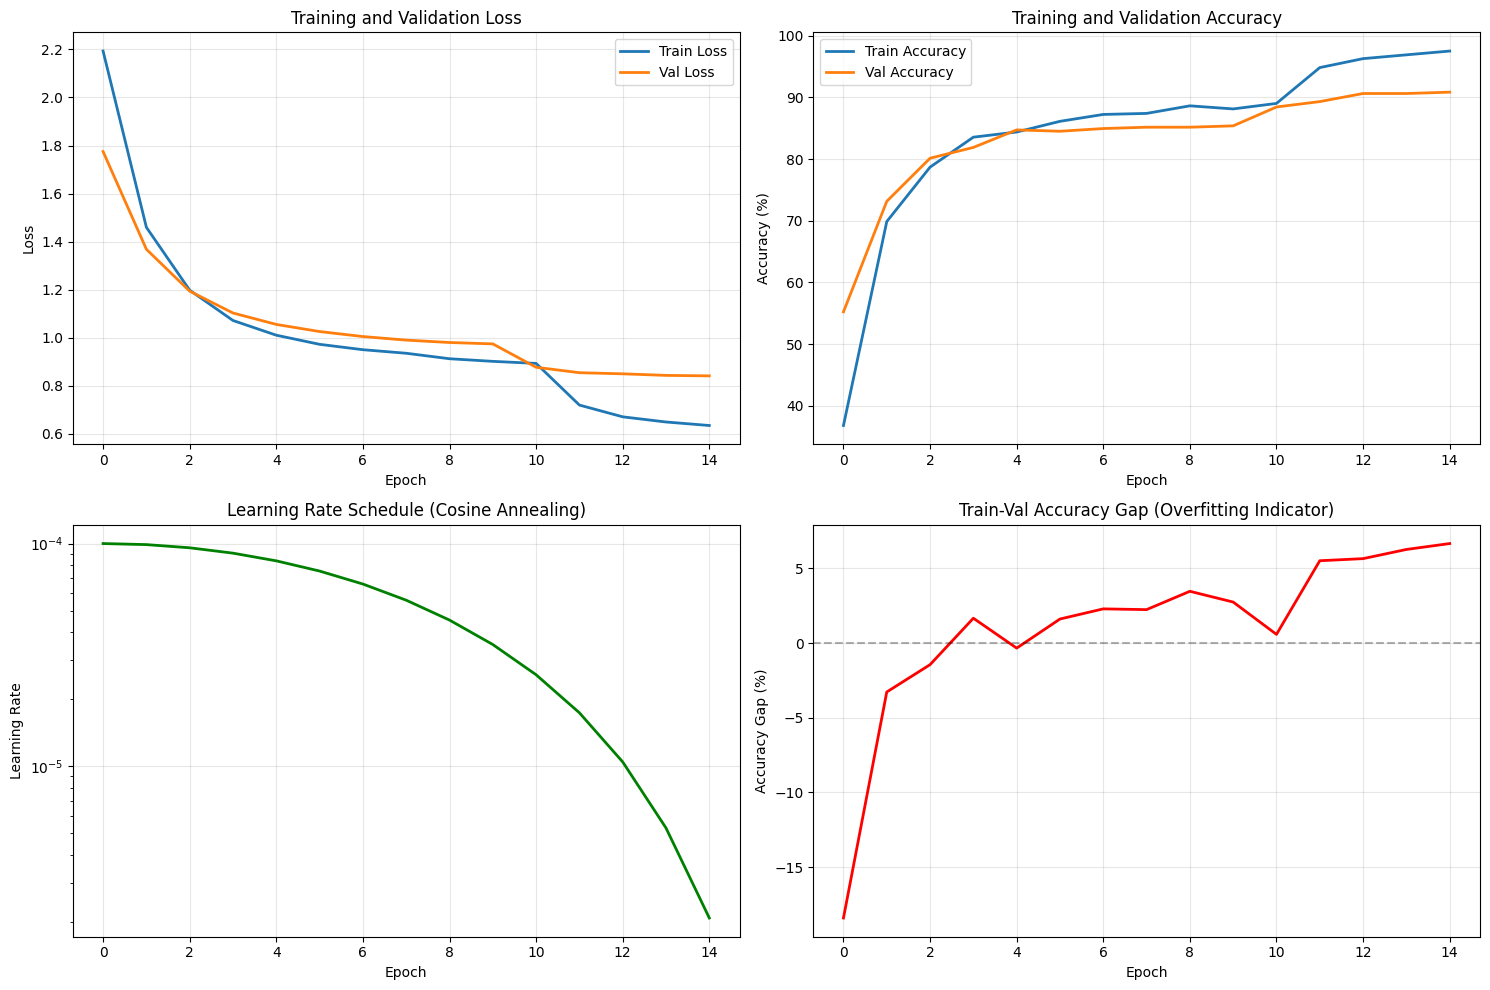


📊 Training Summary:
  Final Train Accuracy: 97.49%
  Final Val Accuracy: 90.83%
  Best Val Accuracy: 90.83%
  ✓ Training history plot saved to 'training_history.png'


In [13]:
import matplotlib.pyplot as plt

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Learning rate schedule
axes[1, 0].plot(history['lr'], linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule (Cosine Annealing)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Plot 4: Train/Val gap
gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(gap, linewidth=2, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Gap (%)')
axes[1, 1].set_title('Train-Val Accuracy Gap (Overfitting Indicator)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Training Summary:")
print(f"  Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Best Val Accuracy: {max(history['val_acc']):.2f}%")
print(f"  ✓ Training history plot saved to 'training_history.png'")

## 🔮 Inference Functions

In [14]:
def load_model_for_inference(
    model_path: str = Config.BEST_MODEL_PATH,
    device: Optional[torch.device] = None
) -> Tuple[nn.Module, list]:
    """
    Load a trained model for inference.
    
    Args:
        model_path: Path to the saved model checkpoint
        device: Device to load the model on
        
    Returns:
        model, class_names
    """
    if device is None:
        device = Config.DEVICE
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Create model
    model = HotelRoomClassifier(
        num_classes=checkpoint['config']['num_classes'],
        pretrained=False
    )
    
    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Get class names
    class_names = checkpoint['class_names']
    
    print(f"✓ Model loaded from {model_path}")
    print(f"  Validation Accuracy: {checkpoint['val_acc']:.2f}%")
    print(f"  Classes: {len(class_names)}")
    
    return model, class_names


def predict_image(
    image_path: str,
    model: Optional[nn.Module] = None,
    class_names: Optional[list] = None,
    model_path: str = Config.BEST_MODEL_PATH,
    top_k: int = 5
) -> Dict:
    """
    Predict the class of a single image.
    
    Args:
        image_path: Path to the image file
        model: Trained model (if None, will load from model_path)
        class_names: List of class names
        model_path: Path to model checkpoint
        top_k: Number of top predictions to return
        
    Returns:
        Dictionary containing predictions and probabilities
    """
    # Load model if not provided
    if model is None or class_names is None:
        model, class_names = load_model_for_inference(model_path)
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    transform = get_transforms(is_training=False)
    image_tensor = transform(image).unsqueeze(0).to(Config.DEVICE)
    
    # Predict
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        
        # Get top-k predictions
        top_probs, top_indices = probabilities.topk(top_k, dim=1)
        top_probs = top_probs.cpu().numpy()[0]
        top_indices = top_indices.cpu().numpy()[0]
    
    # Format results
    predictions = []
    for idx, prob in zip(top_indices, top_probs):
        predictions.append({
            'class': class_names[idx],
            'probability': float(prob),
            'percentage': f"{prob * 100:.2f}%"
        })
    
    result = {
        'image_path': image_path,
        'top_prediction': predictions[0]['class'],
        'confidence': predictions[0]['percentage'],
        'top_k_predictions': predictions
    }
    
    return result


def print_prediction(result: Dict):
    """Pretty print prediction results"""
    print("\n" + "="*70)
    print("PREDICTION RESULT")
    print("="*70)
    print(f"Image: {result['image_path']}")
    print(f"\n🏆 Top Prediction: {result['top_prediction']}")
    print(f"   Confidence: {result['confidence']}")
    print(f"\nTop {len(result['top_k_predictions'])} Predictions:")
    print("-" * 70)
    for i, pred in enumerate(result['top_k_predictions'], 1):
        print(f"{i}. {pred['class']:<30} {pred['percentage']:>8}")
    print("="*70)

print("✓ Inference functions defined")

✓ Inference functions defined


## 🖼️ Single Image Prediction

Model created with 14 output classes
Pretrained: False
✓ Model loaded from checkpoints_Additional_Classes/best_convnext_hotel_classifier.pth
  Validation Accuracy: 90.02%
  Classes: 14

PREDICTION RESULT
Image: C:\Users\sanja\Documents\Koala\testing\CS.jpg

🏆 Top Prediction: Dining Room
   Confidence: 89.35%

Top 5 Predictions:
----------------------------------------------------------------------
1. Dining Room                      89.35%
2. Lounge                            3.90%
3. Bedroom                           1.25%
4. BBQ                               0.81%
5. Bathroom                          0.79%


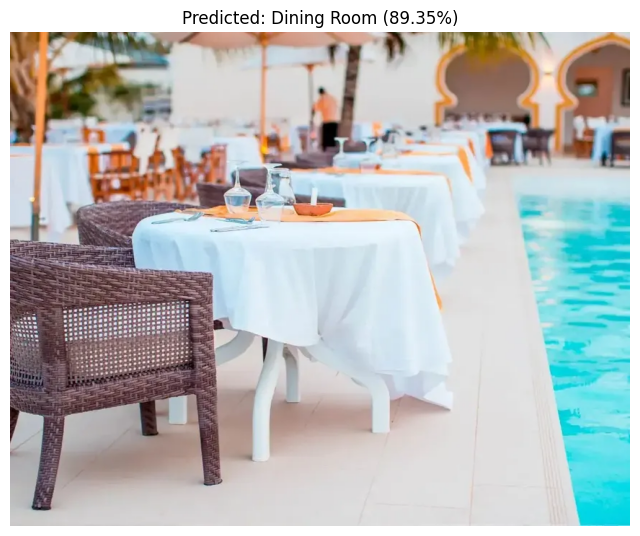

In [17]:
import matplotlib.pyplot as plt
# Predict on a single image
image_path = r"C:\Users\sanja\Documents\Koala\testing\CS.jpg"  # Change this to your image path

if os.path.exists(image_path):
    result = predict_image(image_path)
    print_prediction(result)
    
    # Display the image
    img = Image.open(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Predicted: {result['top_prediction']} ({result['confidence']})")
    plt.axis('off')
    plt.show()
else:
    print(f"⚠️  Image not found: {image_path}")
    print("Please update the image_path variable with a valid image path.")

## 📦 Batch Prediction on Multiple Images

In [15]:
import glob

# Directory containing test images
test_dir = "testing"  # Change this to your test directory

if os.path.exists(test_dir):
    # Get all image files
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        image_paths.extend(glob.glob(os.path.join(test_dir, ext)))
    
    if len(image_paths) > 0:
        print(f"Found {len(image_paths)} images to predict")
        
        # Load model once for efficiency
        model, class_names = load_model_for_inference()
        
        # Predict all images
        results = []
        print("\nMaking predictions...")
        
        for img_path in tqdm(image_paths, desc="Predicting"):
            result = predict_image(img_path, model=model, class_names=class_names)
            results.append(result)
        
        # Display summary
        print(f"\n{'Image':<40} {'Prediction':<25} {'Confidence'}")
        print("-" * 80)
        for r in results:
            print(f"{os.path.basename(r['image_path']):<40} {r['top_prediction']:<25} {r['confidence']}")
        
        # Prediction distribution
        from collections import Counter
        pred_counts = Counter([r['top_prediction'] for r in results])
        
        print(f"\n\nPrediction Distribution:")
        for class_name, count in pred_counts.most_common():
            print(f"  {class_name}: {count} images ({count/len(results)*100:.1f}%)")
    else:
        print(f"⚠️  No images found in {test_dir}")
else:
    print(f"⚠️  Directory not found: {test_dir}")
    print("Please update the test_dir variable with a valid directory path.")

Found 34 images to predict
Model created with 14 output classes
Pretrained: False
✓ Model loaded from checkpoints_26_02/best_convnext_hotel_classifier.pth
  Validation Accuracy: 90.83%
  Classes: 14

Making predictions...


Predicting:   0%|          | 0/34 [00:00<?, ?it/s]


Image                                    Prediction                Confidence
--------------------------------------------------------------------------------
Bathroom.jpg                             Bathroom                  89.52%
BBQ.jpg                                  BBQ                       56.45%
Bed_Room.jpg                             Bedroom                   89.99%
Common_Space.jpg                         Dining Room               43.25%
Common_Space_1.jpg                       Common Space              30.65%
CS.jpg                                   Dining Room               91.76%
dinning.jpg                              Dining Room               83.41%
Exterior.jpg                             Exterior                  95.59%
hqdefault.jpg                            Living room               19.11%
kari-shea-tOVmshavtoo-unsplash.jpg       Study Room                79.51%
Kitchen.jpg                              Kitchen                   85.78%
living-room.jpg           

## 💾 Export Predictions to CSV

In [ ]:
import csv
import pandas as pd

# Assuming you already have 'results' from the batch prediction above
if 'results' in locals() and len(results) > 0:
    # Create DataFrame
    data = []
    for r in results:
        row = {
            'image_filename': os.path.basename(r['image_path']),
            'image_path': r['image_path'],
            'top_1_class': r['top_k_predictions'][0]['class'],
            'top_1_confidence': r['top_k_predictions'][0]['probability'],
        }
        # Add top 3 predictions
        for i in range(1, min(3, len(r['top_k_predictions']))):
            row[f'top_{i+1}_class'] = r['top_k_predictions'][i]['class']
            row[f'top_{i+1}_confidence'] = r['top_k_predictions'][i]['probability']
        data.append(row)
    
    df = pd.DataFrame(data)
    
    # Save to CSV
    output_file = 'predictions.csv'
    df.to_csv(output_file, index=False)
    print(f"✓ Predictions exported to {output_file}")
    
    # Display first few rows
    print("\nFirst 5 predictions:")
    display(df.head())
else:
    print("⚠️  No predictions available. Run the batch prediction cell first.")

## 🎨 Visualize Sample Predictions

In [ ]:
# Visualize a grid of predictions
if 'results' in locals() and len(results) > 0:
    n_samples = min(9, len(results))  # Show up to 9 images
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    
    for i in range(n_samples):
        img = Image.open(results[i]['image_path'])
        axes[i].imshow(img)
        axes[i].set_title(
            f"{results[i]['top_prediction']}\n{results[i]['confidence']}",
            fontsize=10
        )
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(n_samples, 9):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Sample predictions saved to 'sample_predictions.png'")
else:
    print("⚠️  No predictions available. Run the batch prediction cell first.")

## 📈 Model Performance Analysis

In [ ]:
# Analyze confidence distribution
if 'results' in locals() and len(results) > 0:
    confidences = [r['top_k_predictions'][0]['probability'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(confidences, bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Number of Predictions')
    axes[0].set_title('Confidence Distribution')
    axes[0].axvline(x=0.8, color='r', linestyle='--', label='80% threshold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    axes[1].boxplot(confidences, vert=True)
    axes[1].set_ylabel('Confidence')
    axes[1].set_title('Confidence Statistics')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nConfidence Statistics:")
    print(f"  Mean: {np.mean(confidences):.4f}")
    print(f"  Median: {np.median(confidences):.4f}")
    print(f"  Std Dev: {np.std(confidences):.4f}")
    print(f"  Min: {np.min(confidences):.4f}")
    print(f"  Max: {np.max(confidences):.4f}")
    print(f"\n  Predictions > 80% confidence: {sum(1 for c in confidences if c > 0.8)} ({sum(1 for c in confidences if c > 0.8)/len(confidences)*100:.1f}%)")
    print(f"  Predictions > 90% confidence: {sum(1 for c in confidences if c > 0.9)} ({sum(1 for c in confidences if c > 0.9)/len(confidences)*100:.1f}%)")
else:
    print("⚠️  No predictions available. Run the batch prediction cell first.")

## 🎯 Summary & Next Steps

### What You've Accomplished:
- ✅ Loaded and preprocessed hotel room image data
- ✅ Built a ConvNeXt-Tiny classifier
- ✅ Trained with two-stage fine-tuning
- ✅ Made predictions on new images
- ✅ Analyzed model performance

### Next Steps:
1. **Improve Performance**: Collect more data, adjust hyperparameters
2. **Deploy**: Export model to ONNX for production deployment
3. **Monitor**: Track predictions in real-world scenarios
4. **Iterate**: Continuously improve based on feedback

### Useful Resources:
- [PyTorch Documentation](https://pytorch.org/docs/)
- [timm Documentation](https://huggingface.co/docs/timm/)
- [ConvNeXt Paper](https://arxiv.org/abs/2201.03545)